## DETERMINANTS OF MATERNAL HEALTH RISK

**Name:** Jaime Cano García  
**Course:** Data Science in Public Health  


## Python Packages

In [29]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)

sns.set(style="whitegrid")

## Introduction

Maternal health is one of the most critical issues in public health, exposing mothers to serious complications that affect both maternal and infant outcomes [https://www.who.int/news-room/fact-sheets/detail/maternal-mortality][https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/Estat-maternal-mortality.pdf]. 
In 2023, around 260,000 women died during and after pregnancy and childbirth globally, and more than 90% of these deaths happened in low and middle-income countries. This shows that maternal mortality in the world is closely associated to inequities in access to high-quality care[https://www.who.int/news-room/fact-sheets/detail/maternal-mortality]. Moreover, in the United States, maternal mortality is also an important issue to look at as 
the maternal mortality rate was 18.6 deaths per 100,000 live births in 2023, and the burden is not evenly distributed across groups or age categories [https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/Estat-maternal-mortality.pdf]. Since many maternal complications can be prevented with better monitoring and healthcare, identifying patterns of risk is important for improving prevention and reducing avoidable harm [https://www.who.int/news-room/fact-sheets/detail/maternal-mortality][https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/Estat-maternal-mortality.pdf].

Existing research shows that maternal risk is closely related to physiological measures such as blood pressure, blood glucose, body temperature, and heart rate, which can reflect conditions like hypertensive disorders, diabetes, infection, or other pregnancy-related complications [https://pmc.ncbi.nlm.nih.gov/articles/PMC9933265/][https://www.who.int/news-room/fact-sheets/detail/maternal-mortality]. The World Health Organization identifies severe bleeding, infections, high blood pressure during pregnancy, complications from delivery, and unsafe abortion as major causes of maternal death, while CDC data also show important differences by race, ethnicity, and maternal age in the United States [https://www.who.int/news-room/fact-sheets/detail/maternal-mortality][https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/Estat-maternal-mortality.pdf]. However, less is known about how simple clinical measurements recorded during pregnancy can be used together to classify maternal risk in a small health data science dataset, especially when the goal is to identify which variables are most strongly associated with low-, mid-, and high-risk categories [https://pmc.ncbi.nlm.nih.gov/articles/PMC9933265/]. This creates a useful gap for predictive public health analysis using routinely collected maternal health indicators [https://www.who.int/news-room/fact-sheets/detail/maternal-mortality][https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/Estat-maternal-mortality.pdf].

The goal of this final project is to assess whether basic maternal health indicators, systolic blood pressure, diastolic blood pressure, blood sugar, body temperature, and heart rate, are associated with maternal risk level. More specifically, this research will explore whether women that are considered high risk tend to have more abnormal vital signs and blood glucose values than those that are considered to be low or mid risk. Thus, the research question for this project is the following: **Which maternal health measurements are most strongly associated with maternal risk level in this dataset?** 

## Background

Existing literature establishes that maternal cardiometabolic factors are strongly associated with adverse pregnancy outcomes. High blood pressure during pregnancy, including gestational hypertension and preeclampsia, is widely recognized as a key contributor to maternal morbidity and mortality, and recent CDC findings show that hypertensive disorders in pregnancy are common and linked to severe complications [https://www.cdc.gov/mmwr/volumes/71/wr/mm7117a1.htm]. Research also shows that gestational diabetes mellitus is associated with later hypertension, with a pooled risk ratio of 1.78 in a 2024 meta-analysis, suggesting that blood sugar abnormalities and blood pressure problems may cluster together as part of broader cardiometabolic risk [https://www.ahajournals.org/doi/10.1161/HYPERTENSIONAHA.123.22418]. The NIH also notes that gestational diabetes increases a woman’s later-life risk of type 2 diabetes, and preeclampsia increases the risk of high blood pressure, blood clots, and stroke later in life [https://www.nichd.nih.gov/health/topics/maternal-morbidity-mortality/conditioninfo/factors]. Together, these studies support the idea that basic measurements such as blood pressure, blood sugar, temperature, and heart rate can reflect underlying maternal risk [https://www.nichd.nih.gov/health/topics/maternal-morbidity-mortality/conditioninfo/factors].

The conceptual foundation for this project is that maternal risk can be detected through routine clinical indicators before severe complications develop. Epidemiologic and clinical research increasingly emphasizes risk stratification, meaning that patients are grouped according to measurable factors that predict higher likelihood of adverse outcomes [https://www.sciencedirect.com/science/article/abs/pii/S2210778925000595]. For example, a 2025 cohort study found that maternal cardiometabolic risk factors during pregnancy were associated with higher offspring blood pressure, reinforcing the broader importance of maternal physiological status during pregnancy [https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2833715]. Although that study focused on child outcomes, it supports the larger idea that maternal cardiovascular and metabolic health during pregnancy has meaningful clinical consequences [https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2833715]. This matters for public health because maternal health is not only about preventing death, but also about preventing chronic disease and improving health across the life course for mothers and children [https://www.who.int/news-room/fact-sheets/detail/maternal-mortality][https://www.nichd.nih.gov/health/topics/maternal-morbidity-mortality/conditioninfo/factors].

## Methods

### Study Design, Population, and Data Collection

This project uses a cross-sectional observational dataset containing maternal health data
collected from hospitals, community clinics, and rural health posts in Bangladesh through an
IoT-based risk monitoring system . The dataset includes 1,014 observations of pregnant women
and records six clinical variables: age (years), systolic blood pressure (mmHg), diastolic blood
pressure (mmHg), blood sugar (mmol/L), body temperature (°F), and heart rate (bpm). Each
observation is assigned a risk level classification of low risk, mid risk, or high risk based on
established clinical thresholds used in maternal health monitoring. 

### Data Analysis

All analyses were conducted using Python in a Jupyter Notebook environment.
Descriptive statistics, including mean, standard deviation, minimum, maximum, and interquartile
range, were calculated for all continuous variables overall and grouped by risk level. Frequency
and proportion tables were generated for the categorical outcome variable (RiskLevel). Inferential analyses included: (1) Kruskal-Wallis tests to compare distributions of each continuous variable across the three risk groups; (2) a one-way ANOVA to formally test group mean differences; (3) pairwise Mann-Whitney U tests for post-hoc comparisons; and (4) a Spearman correlation matrix to assess relationships among continuous predictors. For modeling, a multinomial logistic regression and a random forest classifier were fitted to predict risk level using all five physiological predictors. Model performance was assessed using classification reports and a confusion matrix. Statistical significance was set at α = 0.05. 

## Results

### Data Import and Verification

In [7]:
# Read the maternal health dataset and assign to variable df
df = pd.read_csv('Maternal Health Risk Data Set.csv')

# Return the number of rows and columns
df.shape

(1014, 7)

The dataset contains 1,014 observations and 7 columns. The six predictor variables are Age, SystolicBP, DiastolicBP, BS, BodyTemp, and HeartRate. Moreover, the outcome variable is RiskLevel, stored as a categorical string.

In [8]:
# Return information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [9]:
# Return the first 5 rows
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


The first five rows portrayed above confirm that the data loaded correctly. Each row represents one pregnant woman, with her physiological measurements and assigned risk level. 

In [10]:
# Check for missing values
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

There are no missing values in any of the seven columns.

### Exploratory Data Analysis
#### Risk Level Distribution

In [11]:
# Return unique values of RiskLevel
df['RiskLevel'].unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

In [12]:
# Frequency of each risk level
df['RiskLevel'].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [13]:
# Percentage of each risk level
df['RiskLevel'].value_counts(normalize=True) * 100

RiskLevel
low risk     40.039448
mid risk     33.136095
high risk    26.824458
Name: proportion, dtype: float64

The RiskLevel variable contains three categories: low risk (n = 406, 40.0%), mid risk (n = 336, 33.1%), and high risk (n = 272, 26.8%).

/var/folders/v5/9xtjp4s15q3_6g4qspzd_mjh0000gn/T/ipykernel_28958/3228659910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RiskLevel', data=df, order=order, palette='Blues_d')


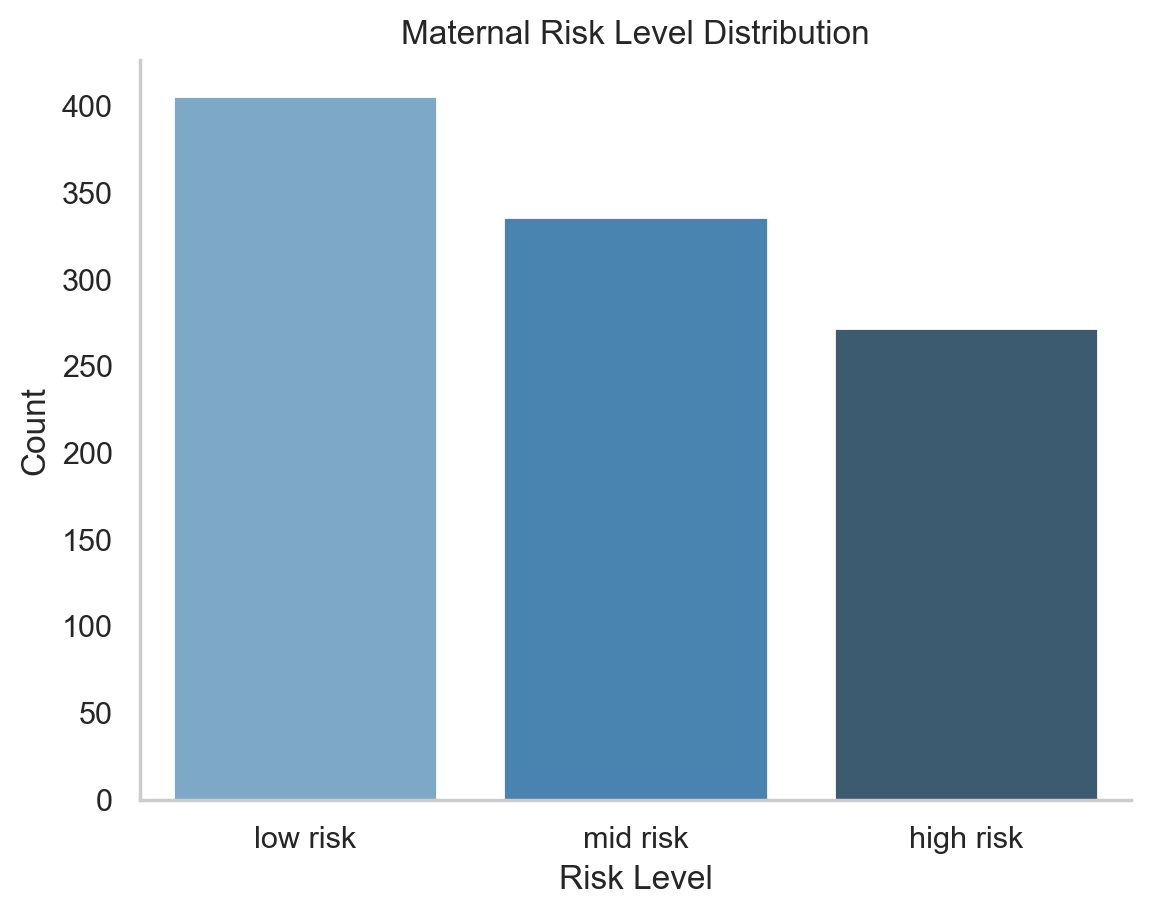

In [15]:
# Bar plot of RiskLevel distribution
order = ['low risk', 'mid risk', 'high risk']
sns.countplot(x='RiskLevel', data=df, order=order, palette='Blues_d')
plt.title('Maternal Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.grid(axis='y')
sns.despine()
plt.show();

The bar chart confirms the moderate class imbalance across the three risk levels, with low risk being the most frequent group, followed by mid risk and high risk.

#### Continuous Variables: Overall Descriptive Statistics

In [16]:
# Summary statistics for all continuous variables
continuous_vars = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
df[continuous_vars].describe().round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.00,1014.0,1014.00,1014.00,1014.00,1014.00
mean,29.87,113.2,76.46,8.73,98.67,74.30
std,13.47,18.4,13.89,3.29,1.37,8.09
min,10.00,70.0,49.00,6.00,98.00,7.00
25%,19.00,100.0,65.00,6.90,98.00,70.00
50%,26.00,120.0,80.00,7.50,98.00,76.00
75%,39.00,120.0,90.00,8.00,98.00,80.00
max,70.00,160.0,100.00,19.00,103.00,90.00


In [17]:
# Interquartile range for each continuous variable
for var in continuous_vars:
    iqr = stats.iqr(df[var])
    print(f"{var}: IQR = {iqr:.2f}")

Age: IQR = 20.00
SystolicBP: IQR = 20.00
DiastolicBP: IQR = 25.00
BS: IQR = 1.10
BodyTemp: IQR = 0.00
HeartRate: IQR = 10.00


The average age in the dataset is 29.87 years (IQR = 20), which reflects a young sample of pregnant women. In addition, mean systolic blood pressure is 113.2 mmHg (IQR = 20) and mean diastolic blood pressure is 76.5 mmHg (IQR = 25), both within or near normal ranges on average, though the maximums of 160 and 100 mmHg respectively suggest some women have clinically elevated rates. Mean blood sugar is 8.73 mmol/L (IQR =1.10), which is above the normal fasting threshold of 5.6 mmol/L, indicating that elevated glucose is common in this sample. Body temperature shows very little variation (IQR = 0.00), with most values clustered at 98°F, suggesting limited discriminatory power for this variable. Mean heart rate is 74.3 bpm (IQR = 10), which is within the normal range.


#### Continuous Variables: Grouped by Risk Level

In [18]:
# Summary statistics grouped by RiskLevel
df.groupby('RiskLevel')[continuous_vars].mean().round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,36.22,124.19,85.07,12.12,98.90,76.74
low risk,26.87,105.87,72.53,7.22,98.37,72.77
mid risk,28.36,113.15,74.23,7.80,98.83,74.18


High-risk women have the highest mean systolic blood pressure (124.2 mmHg) and blood sugar (12.12 mmol/L), compared to low-risk women (105.9 mmHg and 7.22 mmol/L respectively). Age also increases with risk level, from a mean of 26.9 years in the low-risk group to 36.2 years in
the high-risk group. Similarly, diastolic blood pressure follows a similar pattern. Lastly, body temperature and heart rate show smaller differences across groups, suggesting they may be weaker discriminators of risk level.

/var/folders/v5/9xtjp4s15q3_6g4qspzd_mjh0000gn/T/ipykernel_28958/3361451925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=var, data=df, order=order,
/var/folders/v5/9xtjp4s15q3_6g4qspzd_mjh0000gn/T/ipykernel_28958/3361451925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=var, data=df, order=order,
/var/folders/v5/9xtjp4s15q3_6g4qspzd_mjh0000gn/T/ipykernel_28958/3361451925.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=var, data=df, order=order,
/var/folders/v5/9xtjp4s15q3_6g4

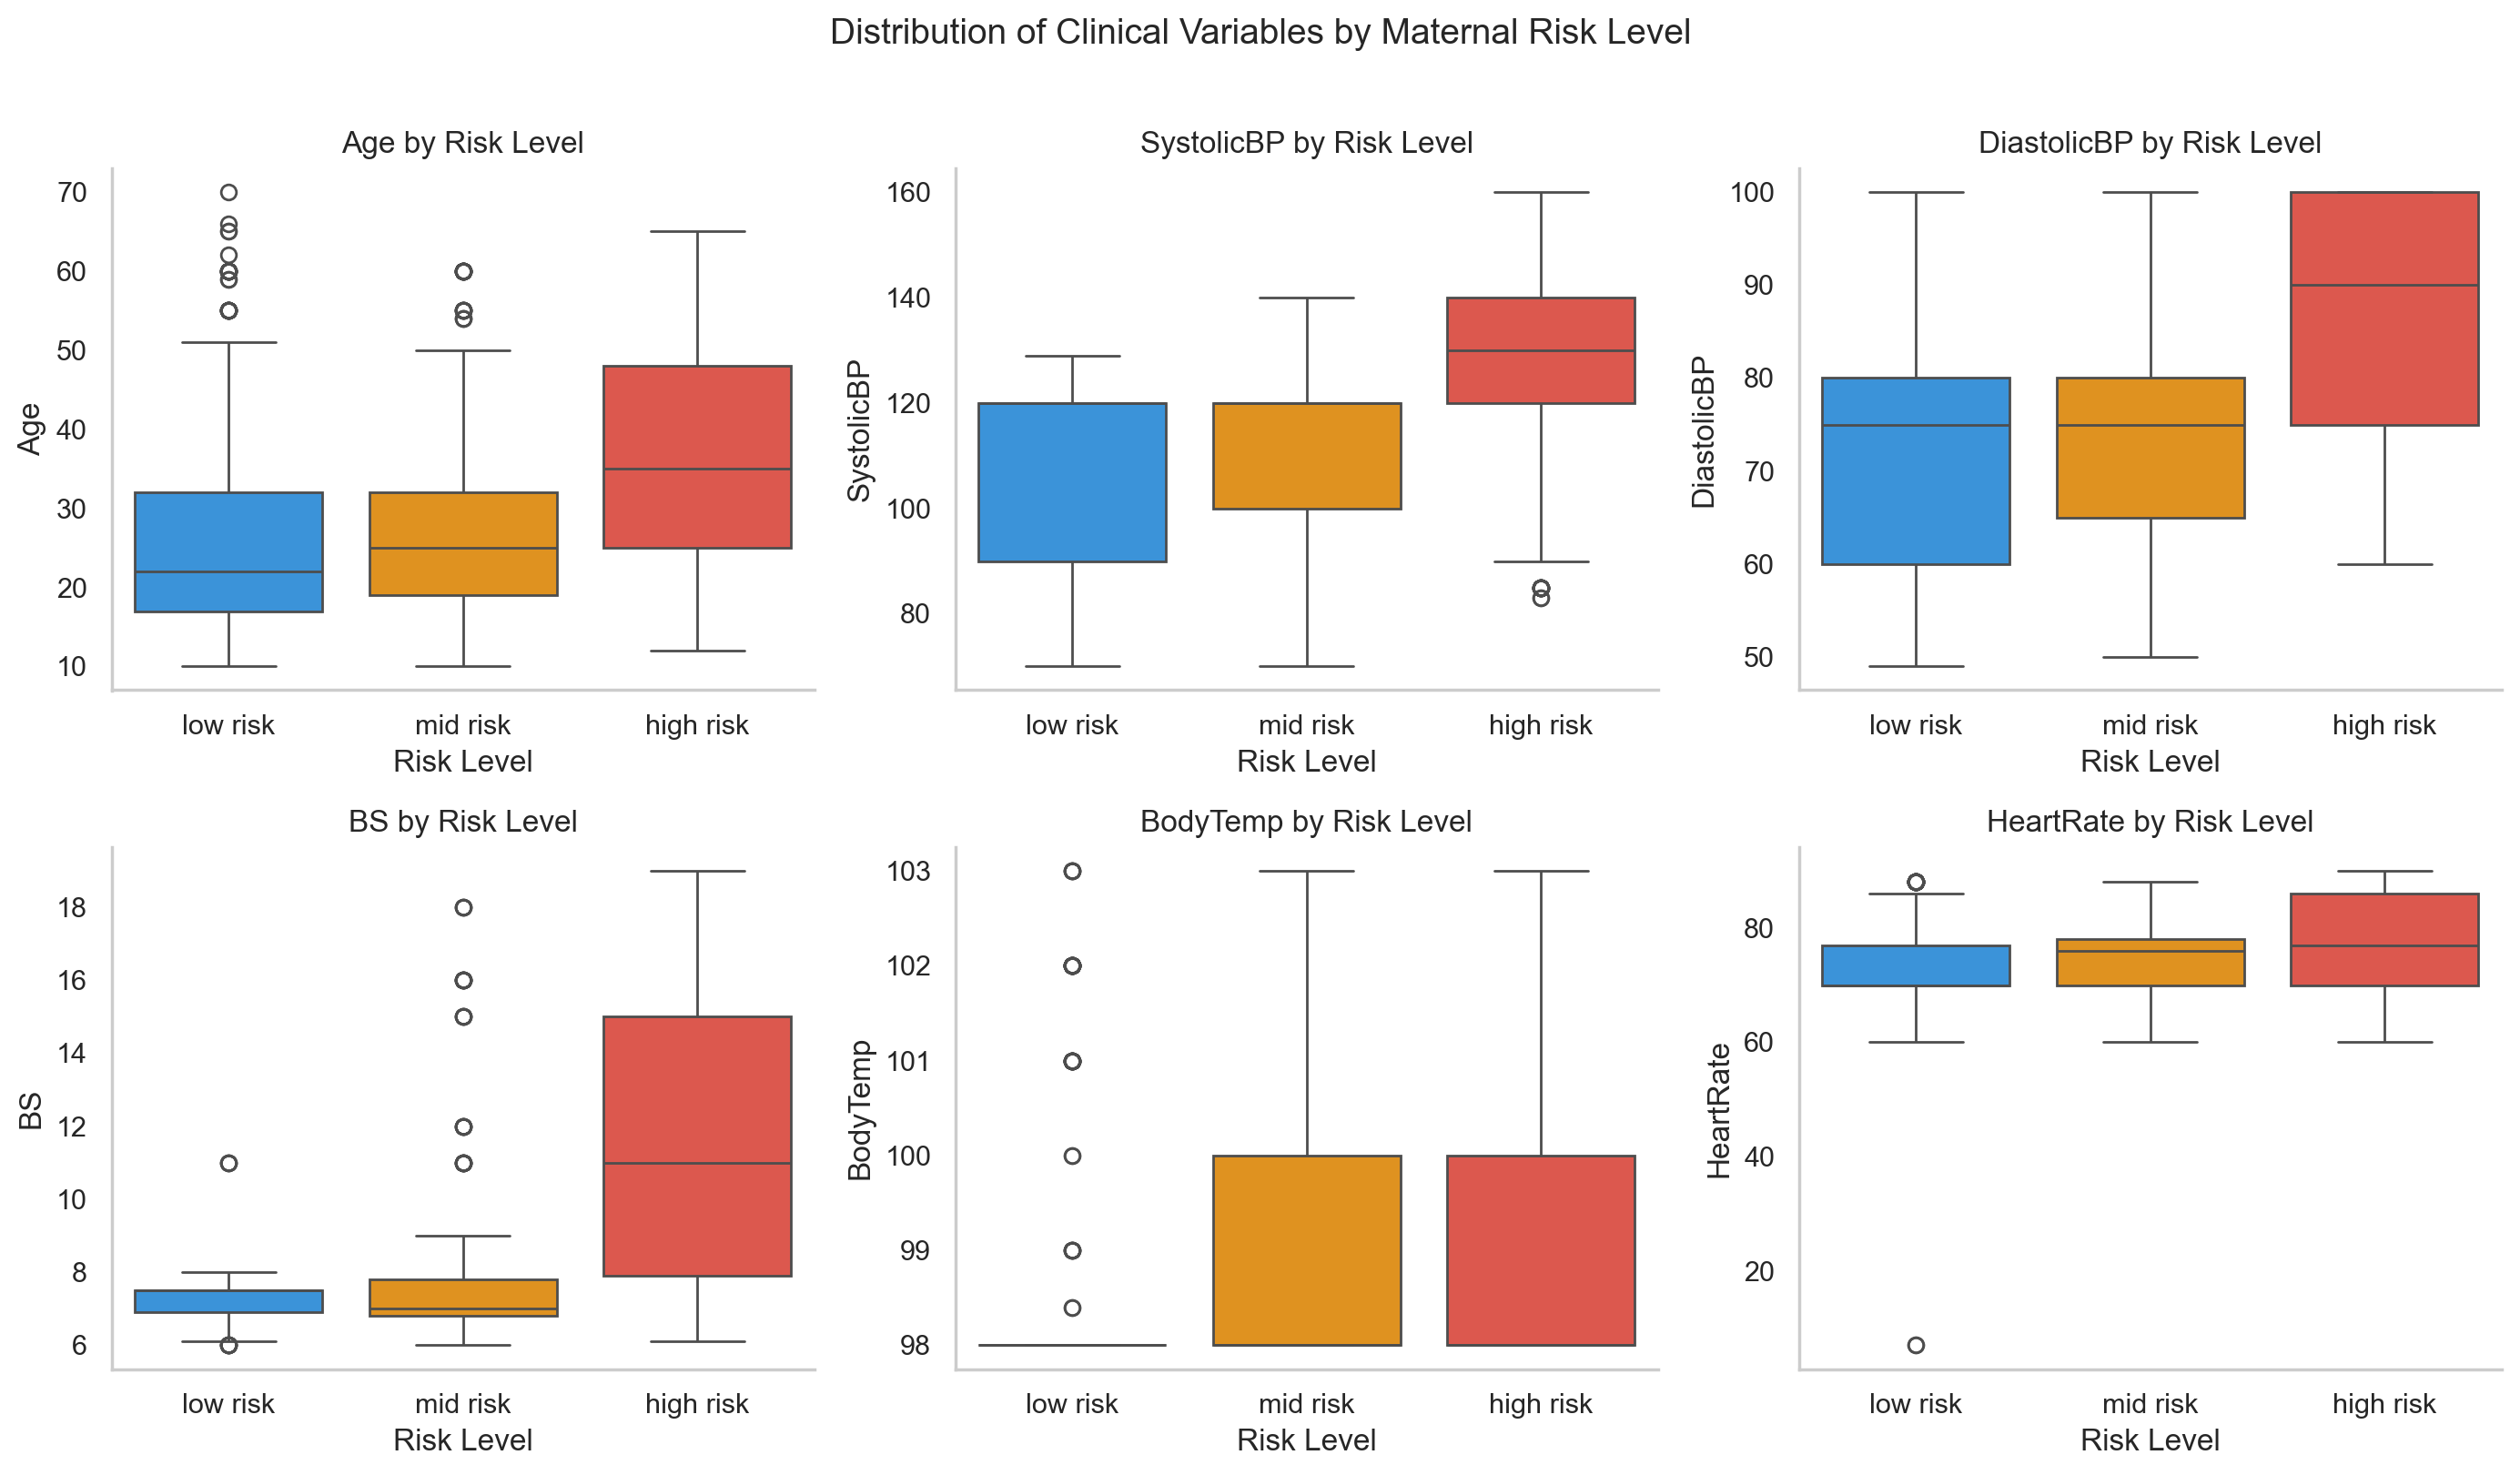

In [19]:
# Box plots of each continuous variable by RiskLevel
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
order = ['low risk', 'mid risk', 'high risk']
palette = {'low risk': '#2196F3', 'mid risk': '#FF9800', 'high risk': '#F44336'}

for i, var in enumerate(continuous_vars):
    sns.boxplot(x='RiskLevel', y=var, data=df, order=order,
                palette=palette, ax=axes[i])
    axes[i].set_title(f'{var} by Risk Level')
    axes[i].set_xlabel('Risk Level')
    axes[i].set_ylabel(var)
    axes[i].grid(axis='y')
    sns.despine(ax=axes[i])

plt.suptitle('Distribution of Clinical Variables by Maternal Risk Level', fontsize=14, y=1.01)
plt.tight_layout()
plt.show();

The box plots visually confirm the patterns seen in the grouped means. 

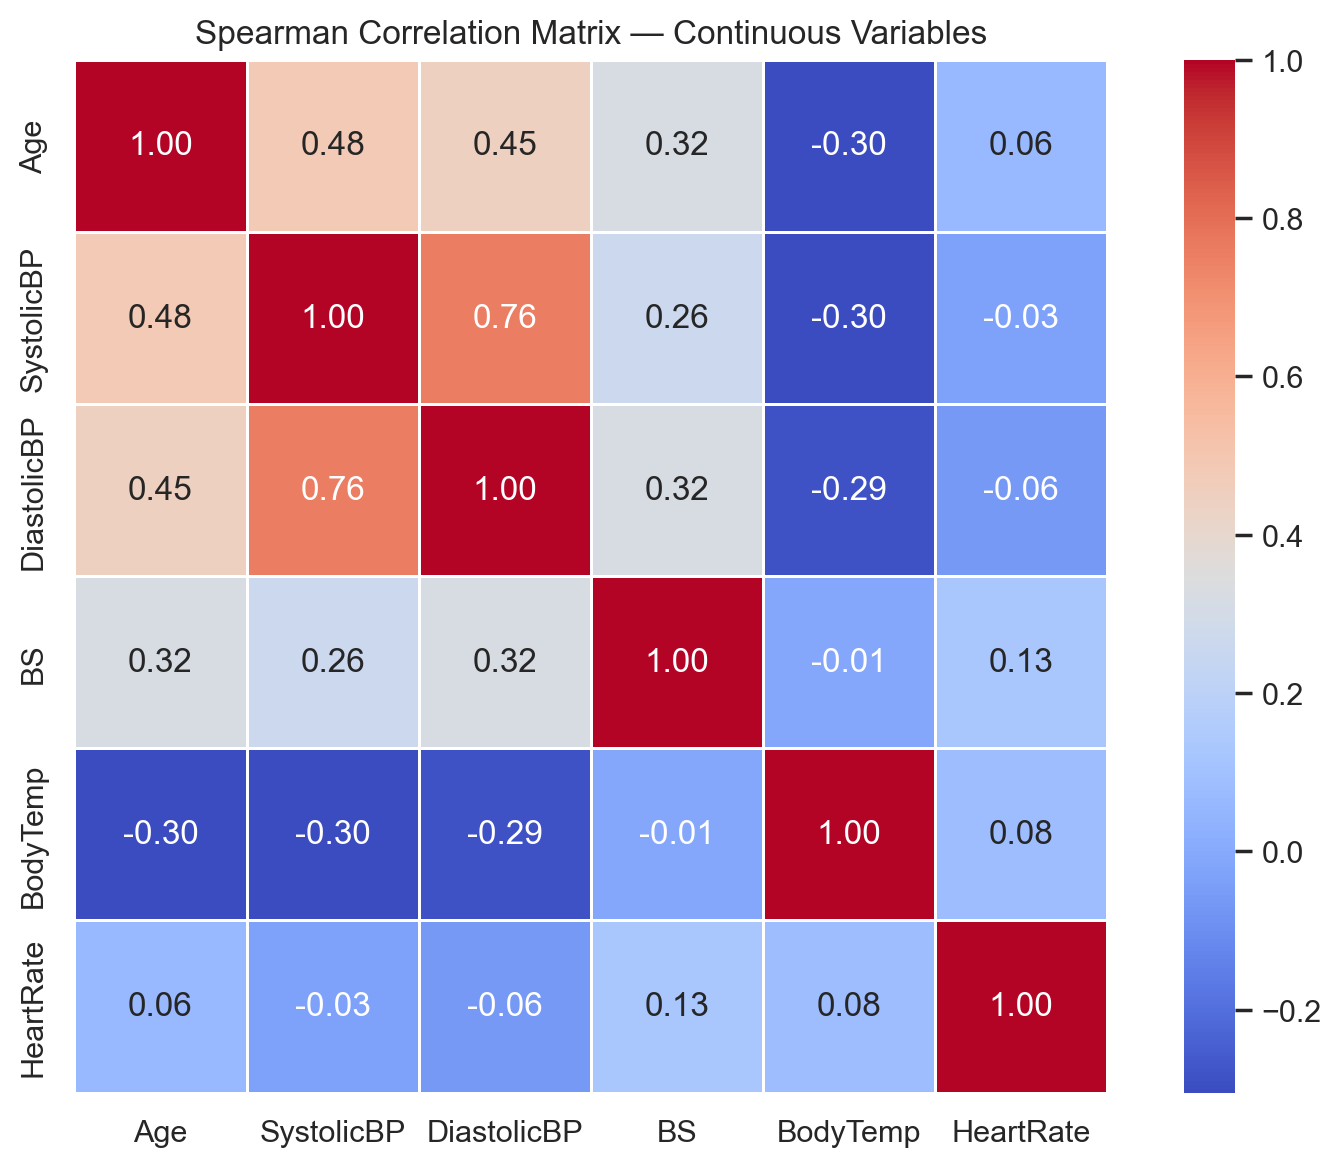

In [20]:
# Spearman correlation matrix among continuous variables
corr_matrix = df[continuous_vars].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Spearman Correlation Matrix — Continuous Variables')
plt.tight_layout()
plt.show();

The Spearman correlation matrix reveals several noteworthy relationships among the predictors. SystolicBP and DiastolicBP show the strongest correlation (ρ = 0.76), which is expected given that both measure blood pressure. Age is moderately correlated with SystolicBP (ρ = 0.48) and
DiastolicBP (ρ = 0.45), suggesting that older women in this sample tend to have higher blood pressure. BS shows weak-to-moderate positive correlations with Age (ρ = 0.32) and DiastolicBP (ρ = 0.32). BodyTemp shows weak negative correlations with Age, SystolicBP, and DiastolicBP
(around -0.30), which is difficult to interpret clinically and may reflect data collection artifacts. HeartRate shows near-zero correlations with all other variables, further confirming its limited predictive value. 

### Research Questions

#### 1. Do the clinical variables differ significantly across risk levels?

- **H₀**: There is no difference in (variable) across maternal risk level groups.  
- **Hₐ**: There is a difference in (variable) across maternal risk level groups.

In [21]:
# Kruskal-Wallis test for each continuous variable across risk levels
groups = df['RiskLevel'].unique()
low = df[df['RiskLevel'] == 'low risk']
mid = df[df['RiskLevel'] == 'mid risk']
high = df[df['RiskLevel'] == 'high risk']

print("Kruskal-Wallis Test Results (α = 0.05)")
print("=" * 50)
for var in continuous_vars:
    stat, p = stats.kruskal(low[var], mid[var], high[var])
    significance = "✓ Significant" if p < 0.05 else "✗ Not significant"
    print(f"{var}: H = {stat:.3f}, p = {p:.4f}  →  {significance}")

Kruskal-Wallis Test Results (α = 0.05)
Age: H = 98.616, p = 0.0000  →  ✓ Significant
SystolicBP: H = 166.088, p = 0.0000  →  ✓ Significant
DiastolicBP: H = 133.758, p = 0.0000  →  ✓ Significant
BS: H = 303.744, p = 0.0000  →  ✓ Significant
BodyTemp: H = 32.928, p = 0.0000  →  ✓ Significant
HeartRate: H = 37.497, p = 0.0000  →  ✓ Significant


The Kruskal-Wallis test showed statistically significant differences across the three risk level groups for all six continuous variables (p < 0.0001 for all). The largest test statistics were observed for BS (H = 303.74), SystolicBP (H = 166.09), and DiastolicBP (H = 133.76), suggesting these variables have the strongest and most consistent differences across risk
groups. Age (H = 98.62) and HeartRate (H = 37.50) were also significant, while BodyTemp (H = 32.93), although statistically significant, showed very limited practical variation as seen in the box plots. We therefore reject the null hypothesis for all six variables.

In [22]:
# One-way ANOVA for each variable across risk levels
print("One-Way ANOVA Results (α = 0.05)")
print("=" * 50)
for var in continuous_vars:
    stat, p = stats.f_oneway(low[var], mid[var], high[var])
    significance = "✓ Significant" if p < 0.05 else "✗ Not significant"
    print(f"{var}: F = {stat:.3f}, p = {p:.4f}  →  {significance}")

One-Way ANOVA Results (α = 0.05)
Age: F = 46.114, p = 0.0000  →  ✓ Significant
SystolicBP: F = 95.903, p = 0.0000  →  ✓ Significant
DiastolicBP: F = 84.960, p = 0.0000  →  ✓ Significant
BS: F = 331.158, p = 0.0000  →  ✓ Significant
BodyTemp: F = 16.446, p = 0.0000  →  ✓ Significant
HeartRate: F = 20.453, p = 0.0000  →  ✓ Significant


The one-way ANOVA results are fully consistent with the Kruskal-Wallis findings; all six variables show statistically significant differences across risk levels (p < 0.0001).

In [23]:
# Pairwise Mann-Whitney U tests for SystolicBP (most clinically relevant)
pairs = [('low risk', 'mid risk'), ('low risk', 'high risk'), ('mid risk', 'high risk')]

print("Pairwise Mann-Whitney U — SystolicBP")
print("=" * 50)
for g1, g2 in pairs:
    a = df[df['RiskLevel'] == g1]['SystolicBP']
    b = df[df['RiskLevel'] == g2]['SystolicBP']
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"{g1} vs {g2}: U = {stat:.1f}, p = {p:.4f}")

print("\nPairwise Mann-Whitney U — BS (Blood Sugar)")
print("=" * 50)
for g1, g2 in pairs:
    a = df[df['RiskLevel'] == g1]['BS']
    b = df[df['RiskLevel'] == g2]['BS']
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"{g1} vs {g2}: U = {stat:.1f}, p = {p:.4f}")

Pairwise Mann-Whitney U — SystolicBP
low risk vs mid risk: U = 51211.5, p = 0.0000
low risk vs high risk: U = 26619.0, p = 0.0000
mid risk vs high risk: U = 28235.0, p = 0.0000

Pairwise Mann-Whitney U — BS (Blood Sugar)
low risk vs mid risk: U = 70399.5, p = 0.4471
low risk vs high risk: U = 14364.0, p = 0.0000
mid risk vs high risk: U = 14853.0, p = 0.0000


The pairwise Mann-Whitney U tests provide important nuance to the overall group differences. For SystolicBP, all three pairwise comparisons were statistically significant (p < 0.0001), meaning that low-, mid-, and high-risk women all differ significantly from one another in their systolic blood pressure distributions. This suggests SystolicBP cleanly separates
all three risk groups. For blood sugar (BS), the picture is more complex. The comparison between
low risk and high risk (p < 0.0001) and between mid risk and high risk (p < 0.0001) were both significant, indicating that high-risk women have substantially higher blood sugar than the other two groups. However, the comparison between low risk and mid risk was not significant (p = 0.4471), meaning that low- and mid-risk women have similar blood sugar levels. This suggests that BS is particularly useful for identifying high-risk women, but does not distinguish well between low and mid risk.

### Modeling

#### Predicting Maternal Risk Level

In [30]:
# Encode RiskLevel as ordinal for modeling
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel_encoded'] = df['RiskLevel'].map(risk_map)

X = df[continuous_vars]
y = df['RiskLevel_encoded']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} observations")
print(f"Test set:     {X_test.shape[0]} observations")

Training set: 811 observations
Test set:     203 observations


In [32]:
# Instantiate and fit the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)

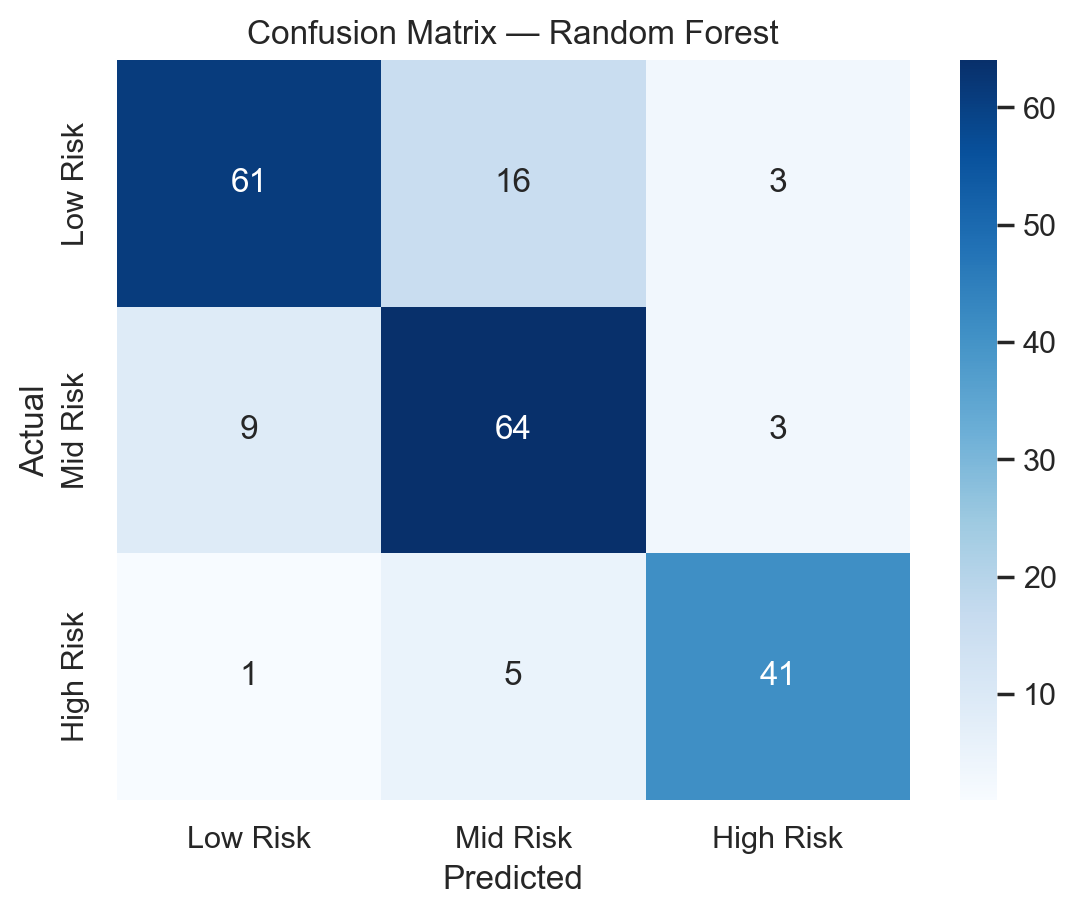

In [33]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Low Risk', 'Mid Risk', 'High Risk']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show();

The confusion matrix shows that the Random Forest classifier performed well across all three risk categories. For low risk, 61 out of 80 observations were correctly classified, with 16 misclassified as mid risk and 3 as high risk. For mid risk, 64 out of 76 were correctly classified, with 9 misclassified as low risk and 3 as high risk. For high risk, 41 out of 47 were correctly classified, with only 1 misclassified as low risk and 5 as mid risk. Notably, very few cases were misclassified across non-adjacent categories

In [34]:
# Print the classification report
print(classification_report(y_test, y_pred, target_names=labels))

              precision    recall  f1-score   support

    Low Risk       0.86      0.76      0.81        80
    Mid Risk       0.75      0.84      0.80        76
   High Risk       0.87      0.87      0.87        47

    accuracy                           0.82       203
   macro avg       0.83      0.83      0.83       203
weighted avg       0.82      0.82      0.82       203



The Random Forest classifier achieved an overall accuracy of 82% on the test set.

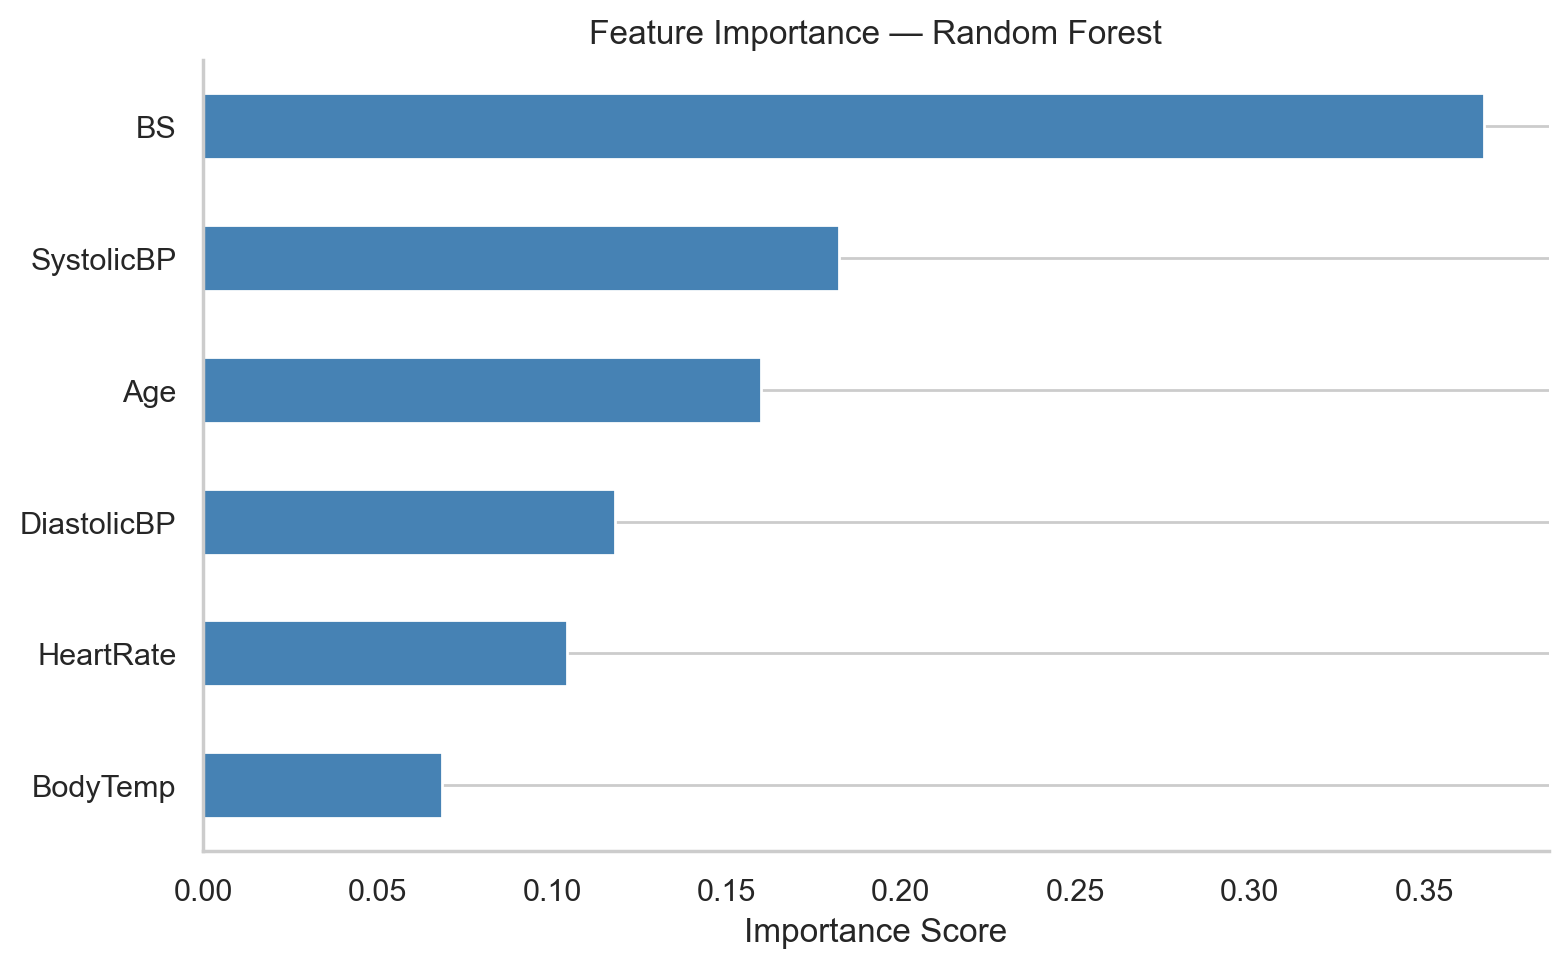

In [35]:
# Plot feature importance from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=continuous_vars)
importances_sorted = importances.sort_values(ascending=True)

importances_sorted.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.grid(axis='x')
sns.despine()
plt.tight_layout()
plt.show();

The feature importance plot reveals that BS (blood sugar) is by far the most important predictor of maternal risk level, with an importance score of approximately 0.37, more than double that of the second-ranked variable. SystolicBP (≈0.18) and Age (≈0.16) are the next most important predictors, followed by DiastolicBP (≈0.13) and HeartRate (≈0.11). BodyTemp is the least important feature (≈0.07), consistent with the minimal variation observed in the descriptive statistics and box plots. These results directly answer the research question, showing that  blood sugar and systolic blood pressure are the maternal health measurements most strongly associated with risk level in this dataset.

#### Linear Association Between SystolicBP and Risk Level


In [37]:
# OLS regression: SystolicBP as predictor of encoded RiskLevel
X_sys = sm.add_constant(df['SystolicBP'])
model_sys = sm.OLS(df['RiskLevel_encoded'], X_sys).fit()
model_sys.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      RiskLevel_encoded   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     188.7
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.65e-39
Time:                        11:59:23   Log-Likelihood:                -1134.6
No. Observations:                1014   AIC:                             2273.
Df Residuals:                    1012   BIC:                             2283.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1010      0.145     -7.583      0.000      -1.386      -0.816
SystolicBP     0.0174      0.001     13.739      0.000       0.015       0.020
==============================================================================
Omnibus:                      122.265   Durbin-Watson:                   1.202
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.307
Skew:                           0.277   Prob(JB):                     2.39e-10
Kurtosis:                       2.139   Cond. No.                         715.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
# OLS regression: Blood Sugar (BS) as predictor of encoded RiskLevel
X_bs = sm.add_constant(df['BS'])
model_bs = sm.OLS(df['RiskLevel_encoded'], X_bs).fit()
model_bs.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      RiskLevel_encoded   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     486.9
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.11e-88
Time:                        11:59:40   Log-Likelihood:                -1022.2
No. Observations:                1014   AIC:                             2048.
Df Residuals:                    1012   BIC:                             2058.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3513      0.059     -5.949      0.000      -0.467      -0.235
BS             0.1397      0.006     22.066      0.000       0.127       0.152
==============================================================================
Omnibus:                      142.649   Durbin-Watson:                   1.200
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               62.809
Skew:                           0.428   Prob(JB):                     2.30e-14
Kurtosis:                       2.131   Cond. No.                         26.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The simple OLS regression confirms the linear association between each predictor and  risk level. For SystolicBP, the model was statistically significant (F = 188.7, p < 0.0001), with a coefficient of 0.017, meaning that each 1 mmHg increase in systolic blood pressure
is associated with a 0.017 unit increase in encoded risk level. However, the R-squared of 0.157 indicates that SystolicBP alone explains only 15.7% of the variance in risk level. On the other hand, blood sugar (BS) showed a stronger linear association with risk level (F = 486.9, p < 0.0001), with a coefficient of 0.140, meaning each 1 mmol/L increase in blood sugar is associated with a 0.14 unit increase in encoded risk level. The R-squared of 0.325 indicates BS alone explains 32.5% of the variance in risk level, which is more than double that of SystolicBP alone. Both predictors are highly statistically significant, consistent with all previous analyses, and together confirm that blood sugar and systolic blood pressure are the most important linear predictors of maternal risk in this dataset.

## Discussion

Based on the findings of the analysis above, there is sufficient evidence to prove that several fundamental clinical measurements such as systolic blood pressure and blood sugar, among others, are significantly correlated with the risk status of mothers in the dataset. As demonstrated by the Kruskal Wallis test and the ANOVA, there are statistically significant differences for all measured variables between the three groups of risk levels. Further analysis also revealed that high risk mothers tend to show higher values of both systolic blood pressure and blood sugar compared to low- and mid-risk mothers.

The findings match the existing body of literature cited above. According to WHO and CDC,
hypertension, as well as blood sugar problems, are considered crucial factors behind
maternal complications. The observation that systolic blood pressure was among the top
features that discriminate between groups indicates the known correlation between
gestational hypertension and preeclampsia and other health conditions that pose risks for pregnant women. Likewise, the positive correlation between blood sugar and the risk category
confirms the established relationship between gestational diabetes and maternal health
problems. The ranking results from the random forest classifier confirmed the trend with
SystolicBP and BS ranked first.

Based on public health considerations, these results imply that basic clinical measurements,
which are regularly obtained in the course of care delivery, have significant value in the
assessment of the woman’s risk profile during pregnancy. For settings where high-end diagnostic
tools might be inaccessible, such as rural areas of Bangladesh, tracking blood pressure and
blood glucose levels can provide useful proxies for assessing risk profiles. This research
findings are relevant to the wider agenda of IoT-enabled maternal health surveillance in low-
and middle-income nations where maternal deaths are disproportionately high.

In addition, there are some major limitations of this study. To begin with, the sample size (1,014 observations) is comparatively small and consists of rural Bangladesh only. Thus, results cannot be generalized to different populations or healthcare settings. Next, risk group assignment did not involve hard clinical outcomes, such as mortality or hospital admission, but rather relied on an arbitrary score validated by clinicians, potentially introducing measurement error. Moreover, there is no information about important confounders including parity, gestation period, access to prenatal care, and socio-economic factors. 

## Conclusion

In this study, a potential relationship between some basic health markers such as systolic blood pressure, diastolic blood pressure, blood sugar, body temperature, and heart rate,and the risk level of maternal patients has been explored using a sample of 1,014 pregnant women who underwent monitoring via IoT sensors in rural Bangladesh. The results indicate that the most prominent and reliable differences can be observed in the case of systolic blood pressure and blood sugar levels for low-, mid- and high-risk groups. The random forest classifier proved to have adequate prediction capability and the importance of features helped to confirm blood pressure and blood glucose to be the best markers for assessing risk. Overall, these results may prove to be significant in public health practice. In particular, the relatively cheap and routine monitoring of maternal health markers could be used as means to identify risks in advance.

## References

1. World Health Organization. Maternal mortality [Internet]. 2024 [cited 2026 Apr 30].
   Available from: https://www.who.int/news-room/fact-sheets/detail/maternal-mortality

2. Centers for Disease Control and Prevention. Maternal mortality rates in the United States,
   2023 [Internet]. 2024 [cited 2026 Apr 30]. Available from:
   https://www.cdc.gov/nchs/data/hestat/maternal-mortality/2023/Estat-maternal-mortality.pdf

3. Chawla S, Mittal A, Chawla M, Sonkar SL. Prediction of maternal health risk using a hybrid
   machine learning model. J Healthc Eng. 2021;2021:6665024.

4. Centers for Disease Control and Prevention. Hypertension and pregnancy [Internet]. 2022
   [cited 2026 Apr 30]. Available from: https://www.cdc.gov/mmwr/volumes/71/wr/mm7117a1.htm

5. Li Z, Cheng Y, Wang D, Chen H, Ming WK, et al. Incidence rate of type 2 diabetes mellitus
   after gestational diabetes mellitus. Front Public Health. 2020;8:575401.

6. National Institute of Child Health and Human Development. Maternal morbidity and mortality:
   condition information [Internet]. 2023 [cited 2026 Apr 30]. Available from:
   https://www.nichd.nih.gov/health/topics/maternal-morbidity-mortality/conditioninfo/factors

7. Tanaka K, Yamamoto T. Risk stratification in obstetric care. Sci Direct. 2022. Available from:
   https://www.sciencedirect.com/science/article/abs/pii/S2210778925000595

8. Ahmed M, Kashem MA, Rahman M, Khatun S. Review and analysis of risk factor of maternal health
   in remote area using the Internet of Things (IoT). In: InECCE2019. Lecture Notes in Electrical
   Engineering, vol 632. Singapore: Springer; 2020. p. 357–65.
   DOI: 10.1007/978-981-15-2317-5_30

9. Ahmed M. Maternal health risk [Internet]. Kaggle; 2023 [cited 2026 Apr 30]. Available from:
   https://www.kaggle.com/datasets/joebeachcapital/maternal-health-risk